# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="/Users/tanvirsingh/Desktop/pythonlab2/DATA3402.Spring.2026/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [4]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [5]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [6]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

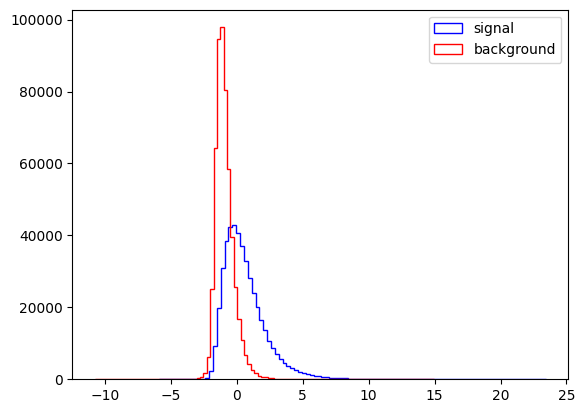

In [7]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

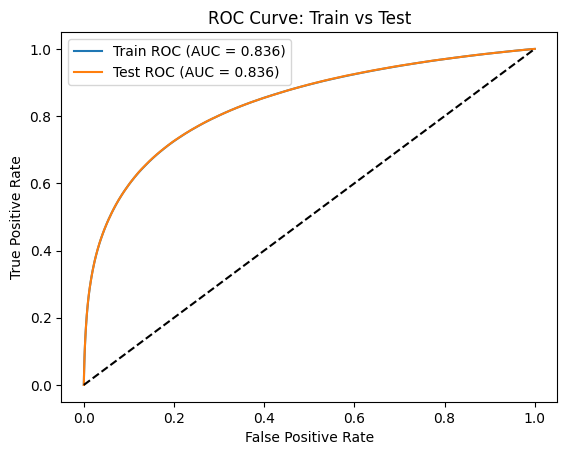

In [8]:
## With AI Assistance
# Train ROC
y_score_train = Fisher.decision_function(X_Train) # from earlier code cell
fpr_train, tpr_train, _ = roc_curve(y_Train, y_score_train)
auc_train = auc(fpr_train, tpr_train)

# Test ROC
y_score_test = Fisher.decision_function(X_Test)
fpr_test, tpr_test, _ = roc_curve(y_Test, y_score_test)
auc_test = auc(fpr_test, tpr_test)

# Plot together
plt.figure()

plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend()
plt.show()

The train ROC curve and the test ROC curve are nearly identical, showing no evidence of bias.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

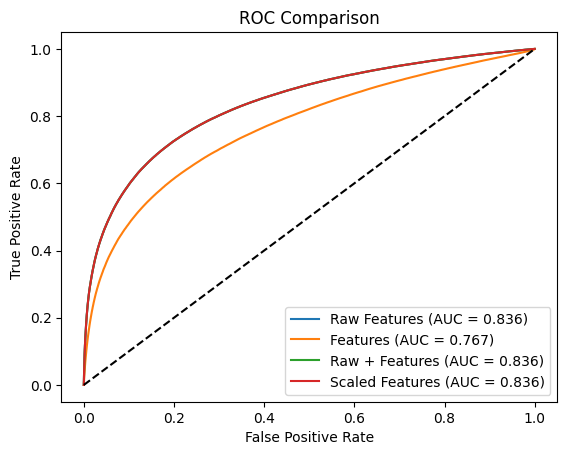

In [9]:
## With AI Assistance
def train_and_roc(X_train, y_train, X_test, y_test, label):

    model = DA.LinearDiscriminantAnalysis()
    model.fit(X_train, y_train)

    scores = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.figure()

# Raw
X_train_raw = X_Train
X_test_raw = X_Test

train_and_roc(X_train_raw, y_Train, X_test_raw, y_Test, "Raw Features")

# Features
X_train_feat = X_Train[["M_R", "M_TR_2", "R"]]
X_test_feat = X_Test[["M_R", "M_TR_2", "R"]]

train_and_roc(X_train_feat, y_Train, X_test_feat, y_Test, "Features")

# Raw + Features
X_train_all = X_Train.copy()
X_test_all = X_Test.copy()

train_and_roc(X_train_all, y_Train, X_test_all, y_Test, "Raw + Features")

# Scaled Features (just to see any impact *personal suggestion*)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_Train)
X_test_scaled = scaler.transform(X_Test)

train_and_roc(X_train_scaled, y_Train, X_test_scaled, y_Test, "Scaled Features")

# Plot
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.show()

The Raw and Raw + Features achieved the same AUC of 0.836. For additional information, I added scaled features and plotted them to see if any difference would be made. The scaled features also achieved the same AUC of 0.836. The only ROC curve that differed was the Features curve that received an AUC of 0.767, which performed much worse. This suggests that only having a limited amount of features for this specific dataset can worsen the model performance. Using Raw + Features is also a redundancy, since both Raw and Raw + Features are essentially the same list of features. Scaling has no observable effect on the curve.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

Part a: I chose to use logistic regression, random forest, and SVC. Logistic regression is a good baseline model for comparison and is effective with linear (or close to linear) patterns in the data. Random forest is good with nonlinear structures and utilizes multiple decision trees to capture more complex interactions in the data. SVC is effective with scaled features which I have already done for the ROC curve. All of these features are also familiar to me.

In [14]:
## Part b
# Logistic Regression (only model that could run)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_Train, y_Train)
lr_scores = lr.decision_function(X_Test)

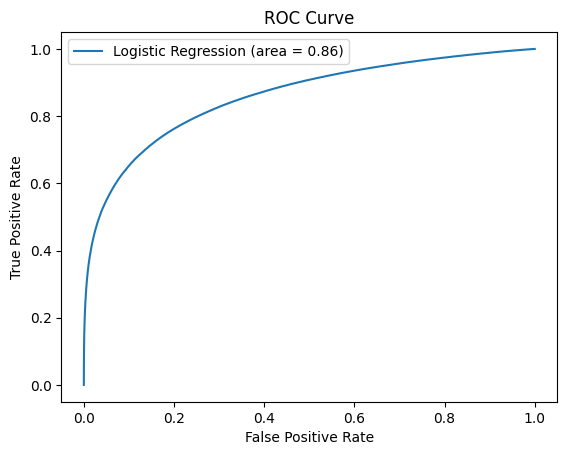

In [15]:
fpr, tpr, _ = roc_curve(y_Test, lr_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

I decided to use logistic regression since it was the only model that did not have a problem running. 

In [17]:
## Part c (With AI assistance)
if hasattr(lr, "predict_proba"):
    scores = lr.predict_proba(X_Test)[:, 1]
else:
    scores = lr.decision_function(X_Test)

In [37]:
# With AI assistance
thresholds = np.percentile(scores, np.linspace(0.01, 0.99, 200))

best_sigma = 0
best_t = 0

for t in thresholds:
    pred = scores > t
    
    N_S = np.sum((pred == 1) & (y_Test == 1))
    N_B = np.sum((pred == 1) & (y_Test == 0))

    if (N_S + N_B) == 0:
        continue
    
    sigma = N_S / np.sqrt(N_S + N_B)
        
    if sigma > best_sigma:
        best_sigma = sigma
        best_t = t

print("Best threshold:", best_t)
print("Max significance:", best_sigma)

Best threshold: 0.05908268918517161
Max significance: 459.77454486613095


- The best threshold is approximately 0.06, which is very low. This can indicate that logistic regression assigns reletively high signal scores to many events, accepting a large fraction of events, some possibly having lower signal likelihood. 
- The high significance of around 460 indicates strong separation between signal and background events for logistic regression and the threshold. This reflects a high signal yield relative to the background fluctuations, which improves the statistical clarity of the result despite the large dataset size.

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

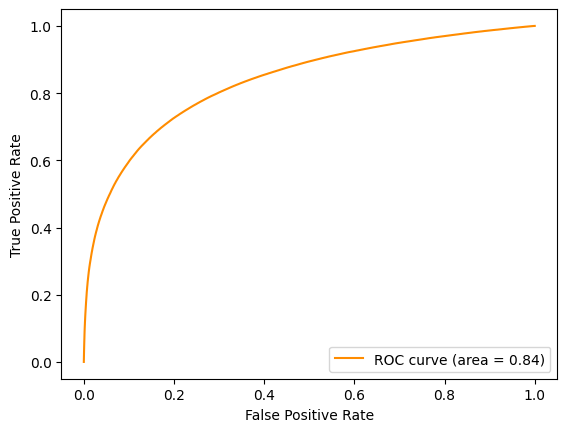

In [13]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [43]:
preds = lr.predict(X_Test)

print("Accuracy:", accuracy_score(y_Test, preds))
print("Precision:", precision_score(y_Test, preds))
print("Recall:", recall_score(y_Test, preds))
print("F1:", f1_score(y_Test, preds))

print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_Test, preds, zero_division=0))

Accuracy: 0.788469
Precision: 0.82958110007321
Recall: 0.6775679621502598
F1: 0.7459084034935778

Logistic Regression Classification Report:

              precision    recall  f1-score   support

         0.0       0.76      0.88      0.82    541767
         1.0       0.83      0.68      0.75    458233

    accuracy                           0.79   1000000
   macro avg       0.80      0.78      0.78   1000000
weighted avg       0.79      0.79      0.79   1000000



In [42]:
preds = Fisher.predict(X_Test)

print("Accuracy:", accuracy_score(y_Test, preds))
print("Precision:", precision_score(y_Test, preds))
print("Recall:", recall_score(y_Test, preds))
print("F1:", f1_score(y_Test, preds))

print("\nFisher Classification Report:\n")
print(classification_report(y_Test, preds, zero_division=0))

Accuracy: 0.757471
Precision: 0.8444914333899756
Recall: 0.5769772146484431
F1: 0.6855618176372893

Fisher Classification Report:

              precision    recall  f1-score   support

         0.0       0.72      0.91      0.80    541767
         1.0       0.84      0.58      0.69    458233

    accuracy                           0.76   1000000
   macro avg       0.78      0.74      0.74   1000000
weighted avg       0.78      0.76      0.75   1000000



I also made a classification report for the Fisher model to compare with my Logistic Regression model. Both models are linear classifiers but the Logistic Regression has a slightly higher accuracy of 0.79. You can also compare the AUC from their ROC curves where logistic regression has an AUC of 0.86 and Fisher has an AUC of 0.84. All around, logistic regression had better performance by a slight amount, especially seen with F1-score and recall of signal. 
Though, the Fisher model had better precision producing fewer false positves (0.84 > 0.83) and has a higher background recall (0.91 > 0.88) compared to logistic regression. This model however seems to be conservative in the fact that it produces fewer false positives, but misses more true signal events. Also its F1-score is not as high as logistic regression, indicating a weak overall balance between precision and recall for signal detection (score 0.69).